--------------------------------------------------
            ### DATA CLEANING
--------------------------------------------------            

In [1]:
# Loading libraries
import pandas as pd        # For data manipulation
import numpy as np         # For working with numeric values
import matplotlib.pyplot as plt

In [2]:
# Load datasets

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

aum_by_fund_house = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

monthly_sip_inflows = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category_inflows = pd.read_csv("../data/raw/05_category_inflows.csv")

industry_folio_count = pd.read_csv("../data/raw/06_industry_folio_count.csv")

scheme_performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

investor_transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

portfolio_holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark_indices = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


# Dataset 1: fund_master.csv

In [3]:
# Show first 5 rows of data
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [4]:
# Understanding dataset metadata
fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


In [5]:
# Correcting datatype of launch_date column
fund_master['launch_date']=pd.to_datetime(fund_master['launch_date'])

In [6]:
# Cross check above operation
fund_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   amfi_code           40 non-null     int64         
 1   fund_house          40 non-null     str           
 2   scheme_name         40 non-null     str           
 3   category            40 non-null     str           
 4   sub_category        40 non-null     str           
 5   plan                40 non-null     str           
 6   launch_date         40 non-null     datetime64[us]
 7   benchmark           40 non-null     str           
 8   expense_ratio_pct   40 non-null     float64       
 9   exit_load_pct       40 non-null     float64       
 10  min_sip_amount      40 non-null     int64         
 11  min_lumpsum_amount  40 non-null     int64         
 12  fund_manager        40 non-null     str           
 13  risk_category       40 non-null     str           
 14  sebi_ca

In [7]:
# Used to view statistical summary
fund_master.describe()

,amfi_code,launch_date,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount
count,40.000000,40,40.000000,40.000000,40.0,40.000000
mean,120247.000000,2007-02-21 10:12:00,1.237000,0.812500,500.0,1277.500000
min,100016.000000,1996-09-11 00:00:00,0.550000,0.000000,500.0,100.000000
25%,118632.750000,2003-12-04 06:00:00,0.787500,1.000000,500.0,1000.000000
50%,119551.500000,2007-04-30 00:00:00,1.425000,1.000000,500.0,1000.000000
75%,120842.250000,2010-10-24 18:00:00,1.540000,1.000000,500.0,1000.000000
max,149324.000000,2015-12-28 00:00:00,1.640000,1.000000,500.0,5000.000000
std,14534.998667,NaN,0.386584,0.387091,0.0,1082.847031


In [8]:
# Total number of rows and columns
fund_master.shape

(40, 15)

In [9]:
# Checking missing values
fund_master.isnull().sum()

amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

In [10]:
# Duplicate values
fund_master.duplicated().sum()

np.int64(0)

In [11]:
# Check unique AMFI codes
fund_master['amfi_code'].nunique()

40

In [12]:
# Check fund categories distribution
fund_master['category'].value_counts()

category
Equity    34
Debt       6
Name: count, dtype: int64

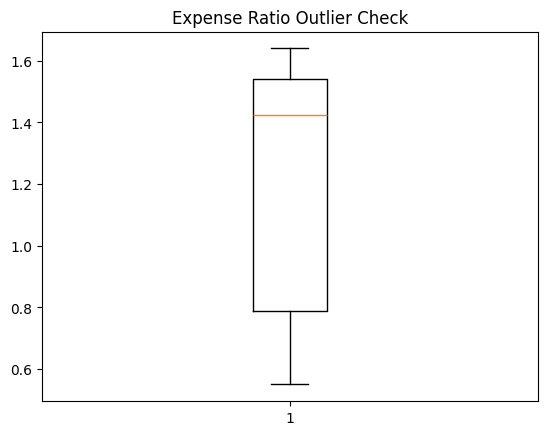

In [13]:
# Outlier check for expense_ratio_pct column
plt.boxplot(fund_master['expense_ratio_pct'])
plt.title("Expense Ratio Outlier Check")
plt.show()

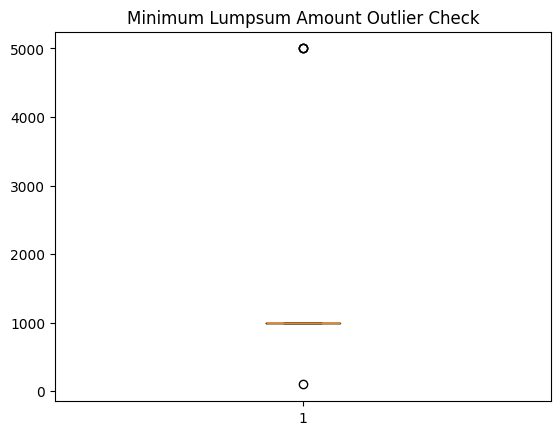

In [14]:
# Outlier check for min_lumpsum_amount column
plt.boxplot(fund_master['min_lumpsum_amount'])
plt.title("Minimum Lumpsum Amount Outlier Check")
plt.show()

In [15]:
# Final dataset
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [16]:
# Load cleaned csv to processed data
fund_master.to_csv(
    "../data/processed/clean_fund_master.csv",
    index=False
)

# Dataset 2: nav_history.csv

In [17]:
# Displays first 5 rows of data
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [18]:
# Views descriptive statistical summary
nav_history.describe()

,amfi_code,nav
count,46000.000000,46000.000000
mean,120247.000000,269.570265
std,14352.317221,577.187060
min,100016.000000,26.136600
25%,118632.750000,69.170425
50%,119551.500000,122.732150
75%,120842.250000,260.338675
max,149324.000000,4268.549700


In [19]:
# Shows total number of rows and columns
nav_history.shape

(46000, 3)

In [20]:
# Displays datatype of all the columns
nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [21]:
# Changed datatype of date column from str to datetime
nav_history['date']=pd.to_datetime(nav_history['date'])

In [22]:
# Cross check datatype after type change
nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [23]:
# Sort values acording to amfi_code and date
nav_history = nav_history.sort_values(
    ['amfi_code','date']
)

In [24]:
# Dataset after SORTING VALUES
nav_history.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [25]:
# check duplicate values
nav_history.duplicated().sum()

np.int64(0)

In [26]:
# check missing values
nav_history.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [27]:
# Invalid NAV values
(nav_history['nav'] <= 0).sum()

np.int64(0)

In [28]:
# Final dataset 
nav_history.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [29]:
# Cleaned csv saved in processed data folder
nav_history.to_csv(
    "../data/processed/clean_nav_history.csv",
    index=False
)

# Dataset 3: aum_by_fund_house.csv

In [30]:
# Displays first 5 rows of data
aum_by_fund_house.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [31]:
# Shows total number of rows and columns
aum_by_fund_house.shape

(90, 5)

In [32]:
# Displays descriptive statistical summary
aum_by_fund_house.describe()

,aum_lakh_crore,aum_crore,num_schemes
count,90.000000,9.000000e+01,90.000000
mean,4.352889,4.352889e+05,152.200000
std,2.734328,2.734328e+05,52.108832
min,1.050000,1.050000e+05,56.000000
25%,2.525000,2.525000e+05,95.000000
50%,3.450000,3.450000e+05,172.500000
75%,5.675000,5.675000e+05,195.000000
max,12.500000,1.250000e+06,216.000000


In [33]:
# Verify datatypes
aum_by_fund_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [34]:
# change datatype of date column to datetime
aum_by_fund_house['date'] = pd.to_datetime(aum_by_fund_house['date'])

In [35]:
# Final datatype check
aum_by_fund_house.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            90 non-null     datetime64[us]
 1   fund_house      90 non-null     str           
 2   aum_lakh_crore  90 non-null     float64       
 3   aum_crore       90 non-null     int64         
 4   num_schemes     90 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 3.6 KB


In [36]:
# Identify missing values in each column
aum_by_fund_house.isnull().sum()

date              0
fund_house        0
aum_lakh_crore    0
aum_crore         0
num_schemes       0
dtype: int64

In [37]:
# Check for duplicate records
aum_by_fund_house.duplicated().sum()

np.int64(0)

In [38]:
# Verify duplicates with date and fund_house column together
aum_by_fund_house.duplicated(subset=['date','fund_house']).sum()

np.int64(0)

In [39]:
# Checking unique number of of fund_house
aum_by_fund_house['fund_house'].nunique()

10

<Axes: >

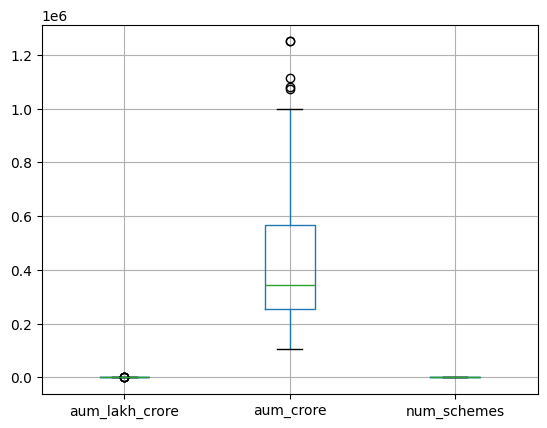

In [40]:
# Checking outliers 
aum_by_fund_house[['aum_lakh_crore','aum_crore','num_schemes']].boxplot()

In [41]:
# Verify that all the entries are in systematic order
aum_by_fund_house['date'].min(), aum_by_fund_house['date'].max()

(Timestamp('2022-03-31 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [42]:
# Final dataset 
aum_by_fund_house.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [43]:
# Cleaned csv saved in processed data folder
aum_by_fund_house.to_csv(
    "../data/processed/clean_aum_by_fund_house.csv",
    index=False
)

# Dataset 4: monthly_sip_inflows.csv

In [44]:
# Top 5 rows of data
monthly_sip_inflows.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [45]:
# Total rows and columns of data
monthly_sip_inflows.shape

(48, 6)

In [46]:
# Displays descriptive statistical summary 
monthly_sip_inflows.describe()

,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
count,48.000000,48.000000,48.000000,48.000000,36.000000
mean,19577.520833,7.189583,9.893750,8.632083,31.456944
std,6354.329621,1.271457,5.370745,3.613579,11.768190
min,11438.000000,4.910000,7.500000,4.800000,15.800000
25%,13658.500000,6.110000,8.775000,5.790000,20.245000
50%,18224.000000,7.150000,9.200000,7.265000,28.295000
75%,25944.250000,8.300000,9.562500,10.525000,40.807500
max,31002.000000,9.350000,46.000000,15.900000,53.050000


In [47]:
# Verify datatype of all the columns
monthly_sip_inflows.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     str    
 1   sip_inflow_crore           48 non-null     int64  
 2   active_sip_accounts_crore  48 non-null     float64
 3   new_sip_accounts_lakh      48 non-null     float64
 4   sip_aum_lakh_crore         48 non-null     float64
 5   yoy_growth_pct             36 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.4 KB


In [48]:
# Convert datatype of month column
monthly_sip_inflows['month'] = pd.to_datetime(
    monthly_sip_inflows['month'],
    format='%Y-%m'
)

In [49]:
# Final datatype of all the columns
monthly_sip_inflows.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   month                      48 non-null     datetime64[us]
 1   sip_inflow_crore           48 non-null     int64         
 2   active_sip_accounts_crore  48 non-null     float64       
 3   new_sip_accounts_lakh      48 non-null     float64       
 4   sip_aum_lakh_crore         48 non-null     float64       
 5   yoy_growth_pct             36 non-null     float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 2.4 KB


In [50]:
# Identify missing values in each column
monthly_sip_inflows.isnull().sum()

month                         0
sip_inflow_crore              0
active_sip_accounts_crore     0
new_sip_accounts_lakh         0
sip_aum_lakh_crore            0
yoy_growth_pct               12
dtype: int64

In [51]:
# Check for duplicate records
monthly_sip_inflows.duplicated().sum()

np.int64(0)

In [52]:
# Check duplicate months
monthly_sip_inflows.duplicated(subset=['month']).sum()

np.int64(0)

In [53]:
# Verify range months 
print(monthly_sip_inflows['month'].min())
print(monthly_sip_inflows['month'].max())

2022-01-01 00:00:00
2025-12-01 00:00:00


In [54]:
# Checks continuity of months
monthly_sip_inflows['month'].diff().value_counts()

month
31 days    27
30 days    16
28 days     3
29 days     1
Name: count, dtype: int64

In [55]:
# Checks if data contains negative values
numeric_cols = [
    'sip_inflow_crore',
    'active_sip_accounts_crore',
    'new_sip_accounts_lakh',
    'sip_aum_lakh_crore'
]

(monthly_sip_inflows[numeric_cols] < 0).sum()

sip_inflow_crore             0
active_sip_accounts_crore    0
new_sip_accounts_lakh        0
sip_aum_lakh_crore           0
dtype: int64

In [56]:
# Final dataset
monthly_sip_inflows.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [57]:
# Cleaned csv saved in processed data folder
monthly_sip_inflows.to_csv(
    "../data/processed/clean_monthly_sip_inflows.csv",
    index=False
)

# Dataset 5: category_inflows.csv

In [58]:
# Top 5 rows of data
category_inflows.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [59]:
# Total rows and columns of data
category_inflows.shape

(144, 3)

In [60]:
# Displays descriptive statistical summary
category_inflows.describe()

,net_inflow_crore
count,144.000000
mean,6473.881944
std,9718.335947
min,437.000000
25%,1801.250000
50%,4148.000000
75%,5304.000000
max,41952.000000


In [61]:
# Verify datatype of all the columns
category_inflows.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    str    
 1   category          144 non-null    str    
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), str(2)
memory usage: 3.5 KB


In [62]:
# Convert datatype of month column
category_inflows['month'] = pd.to_datetime(
    category_inflows['month'],
    format='%Y-%m'
)

In [63]:
# Final datatype of all the columns
category_inflows.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   month             144 non-null    datetime64[us]
 1   category          144 non-null    str           
 2   net_inflow_crore  144 non-null    float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 3.5 KB


In [64]:
# Identify missing values in each column
category_inflows.isnull().sum()

month               0
category            0
net_inflow_crore    0
dtype: int64

In [65]:
# Check for duplicate records
category_inflows.duplicated().sum()

np.int64(0)

In [66]:
# Check duplicate months
category_inflows.duplicated(subset=['month','category']).sum()

np.int64(0)

In [67]:
# Verify range months 
print(category_inflows['month'].min())
print(category_inflows['month'].max())

2024-04-01 00:00:00
2025-03-01 00:00:00


In [68]:
# Checks continuity of months
category_inflows['month'].diff().value_counts()

month
0 days     132
31 days      6
30 days      4
28 days      1
Name: count, dtype: int64

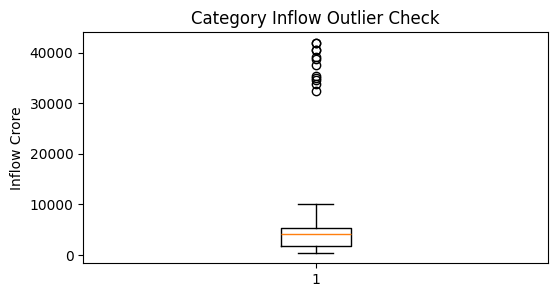

In [69]:
# Outlier check
plt.figure(figsize=(6,3))

plt.boxplot(category_inflows['net_inflow_crore'])

plt.title("Category Inflow Outlier Check")
plt.ylabel("Inflow Crore")

plt.show()

In [70]:
# Final dataset
category_inflows.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [71]:
# Cleaned csv saved in processed data folder
category_inflows.to_csv(
    "../data/processed/clean_category_inflows.csv",
    index=False
)

# Dataset 6: industry_folio_count.csv

In [72]:
# Top 5 rows of data
industry_folio_count.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [73]:
# Total rows and columns of data
industry_folio_count.shape

(21, 6)

In [74]:
# Displays descriptive statistical summary
industry_folio_count.describe()

,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
count,21.000000,21.000000,21.000000,21.000000,21.000000
mean,19.829524,13.880476,2.776190,1.190000,1.983333
std,4.583376,3.207799,0.640308,0.274864,0.459079
min,13.260000,9.280000,1.860000,0.800000,1.330000
25%,15.540000,10.880000,2.180000,0.930000,1.550000
50%,19.980000,13.990000,2.800000,1.200000,2.000000
75%,23.890000,16.720000,3.340000,1.430000,2.390000
max,26.120000,18.280000,3.660000,1.570000,2.610000


In [75]:
# Verify datatype of all the columns
industry_folio_count.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month                21 non-null     str    
 1   total_folios_crore   21 non-null     float64
 2   equity_folios_crore  21 non-null     float64
 3   debt_folios_crore    21 non-null     float64
 4   hybrid_folios_crore  21 non-null     float64
 5   others_folios_crore  21 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.1 KB


In [76]:
# Convert datatype of month column
industry_folio_count['month'] = pd.to_datetime(
    industry_folio_count['month'],
    format='%Y-%m'
)

In [77]:
# Final datatype of all the columns
industry_folio_count.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                21 non-null     datetime64[us]
 1   total_folios_crore   21 non-null     float64       
 2   equity_folios_crore  21 non-null     float64       
 3   debt_folios_crore    21 non-null     float64       
 4   hybrid_folios_crore  21 non-null     float64       
 5   others_folios_crore  21 non-null     float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 1.1 KB


In [78]:
# Identify missing values in each column
industry_folio_count.isnull().sum()

month                  0
total_folios_crore     0
equity_folios_crore    0
debt_folios_crore      0
hybrid_folios_crore    0
others_folios_crore    0
dtype: int64

In [79]:
# Check for duplicate records
industry_folio_count.duplicated().sum()

np.int64(0)

In [80]:
# Check duplicate values in months column
industry_folio_count['month'].duplicated().sum()

np.int64(0)

In [81]:
# Check logical relationship (Total = Equity + Debt + Hybrid + Others)
industry_folio_count['calculated_total'] = (
    industry_folio_count['equity_folios_crore'] +
    industry_folio_count['debt_folios_crore'] +
    industry_folio_count['hybrid_folios_crore'] +
    industry_folio_count['others_folios_crore']
)

industry_folio_count['difference'] = (
    industry_folio_count['total_folios_crore'] -
    industry_folio_count['calculated_total']
)

industry_folio_count['difference'].describe()

count    2.100000e+01
mean    -4.761905e-04
std      7.400129e-03
min     -1.000000e-02
25%     -1.000000e-02
50%      0.000000e+00
75%      3.552714e-15
max      1.000000e-02
Name: difference, dtype: float64

In [82]:
# Final dataset
industry_folio_count.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore,calculated_total,difference
0,2022-01-01,13.26,9.28,1.86,0.80,1.33,13.27,-1.000000e-02
1,2022-04-01,13.91,9.74,1.95,0.83,1.39,13.91,0.000000e+00
2,2022-07-01,13.85,9.69,1.94,0.83,1.38,13.84,1.000000e-02
3,2022-10-01,14.12,9.88,1.98,0.85,1.41,14.12,-1.776357e-15
4,2023-01-01,14.81,10.37,2.07,0.89,1.48,14.81,0.000000e+00


In [83]:
# Cleaned csv saved in processed data folder
industry_folio_count.to_csv(
    "../data/processed/clean_industry_folio_count.csv",
    index=False
)

# Dataset 7: scheme_performance.csv

In [84]:
# Top 5 rows of data
scheme_performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [85]:
# Total rows and columns of data
scheme_performance.shape

(40, 19)

In [86]:
# Display descriptive statistical summary
scheme_performance.describe()

,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000
std,14534.998667,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484
min,100016.000000,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000
25%,118632.750000,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000
50%,119551.500000,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000
75%,120842.250000,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000
max,149324.000000,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,49046.00000,1.640000,5.000000


In [87]:
# Check return values are numeric
scheme_performance.dtypes

amfi_code               int64
scheme_name               str
fund_house                str
category                  str
plan                      str
return_1yr_pct        float64
return_3yr_pct        float64
return_5yr_pct        float64
benchmark_3yr_pct     float64
alpha                 float64
beta                  float64
sharpe_ratio          float64
sortino_ratio         float64
std_dev_ann_pct       float64
max_drawdown_pct      float64
aum_crore               int64
expense_ratio_pct     float64
morningstar_rating      int64
risk_grade                str
dtype: object

In [88]:
# Check missing values in each column
scheme_performance.isnull().sum()

amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

In [89]:
# Check negative Sharpe ratios
negative_sharpe = scheme_performance[
    scheme_performance['sharpe_ratio'] < 0
]

print(negative_sharpe[['scheme_name', 'sharpe_ratio']])

Empty DataFrame
Columns: [scheme_name, sharpe_ratio]
Index: []


In [90]:
# Validate expense ratio (0.1%–2.5%)
invalid_expense = scheme_performance[
    (scheme_performance['expense_ratio_pct'] < 0.1) |
    (scheme_performance['expense_ratio_pct'] > 2.5)
]

print(invalid_expense[
    ['scheme_name', 'expense_ratio_pct']
])

Empty DataFrame
Columns: [scheme_name, expense_ratio_pct]
Index: []


In [91]:
# Check duplicate values
scheme_performance.duplicated().sum()

np.int64(0)

In [92]:
# Check duplicate values in amfi_code column
scheme_performance['amfi_code'].duplicated().sum()

np.int64(0)

In [93]:
# Check ratings
scheme_performance['morningstar_rating'].value_counts()

morningstar_rating
5    17
4    16
3     7
Name: count, dtype: int64

In [94]:
# Final dataset
scheme_performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [95]:
# Cleaned csv saved in processed data folder
scheme_performance.to_csv(
    "../data/processed/clean_scheme_performance.csv",
    index=False
)

# Dataset 8: investor_transactions.csv

In [96]:
# Displays top 5 rows of data
investor_transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [97]:
# Shows total number of rows and columns
investor_transactions.shape

(32778, 13)

In [98]:
# Display descriptive statistical summary
investor_transactions.describe()

,amfi_code,amount_inr,annual_income_lakh
count,32778.000000,32778.000000,32778.000000
mean,120264.617518,107437.318628,26.181219
std,14370.205345,150415.905084,20.805425
min,100016.000000,400.000000,3.000000
25%,118632.000000,3153.000000,10.600000
50%,119551.000000,17782.500000,19.700000
75%,120843.000000,189324.250000,37.400000
max,149324.000000,597498.000000,99.700000


In [99]:
# Check datatype of each column
investor_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [100]:
# Change datatype of transaction_date column to datetime
investor_transactions['transaction_date']= pd.to_datetime(investor_transactions['transaction_date'])

In [101]:
# Verification after type change
investor_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   investor_id         32778 non-null  str           
 1   transaction_date    32778 non-null  datetime64[us]
 2   amfi_code           32778 non-null  int64         
 3   transaction_type    32778 non-null  str           
 4   amount_inr          32778 non-null  int64         
 5   state               32778 non-null  str           
 6   city                32778 non-null  str           
 7   city_tier           32778 non-null  str           
 8   age_group           32778 non-null  str           
 9   gender              32778 non-null  str           
 10  annual_income_lakh  32778 non-null  float64       
 11  payment_mode        32778 non-null  str           
 12  kyc_status          32778 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(9)
memory

In [102]:
# Check unique transaction_type
investor_transactions['transaction_type'].unique()

<StringArray>
['SIP', 'Redemption', 'Lumpsum']
Length: 3, dtype: str

In [103]:
# Validate amount > 0
invalid_amount = investor_transactions[
    investor_transactions['amount_inr'] <= 0
]

print(invalid_amount[['investor_id', 'amount_inr']])

Empty DataFrame
Columns: [investor_id, amount_inr]
Index: []


In [104]:
# Check unique kyc_status
investor_transactions['kyc_status'].unique()

<StringArray>
['Verified', 'Pending']
Length: 2, dtype: str

In [105]:
# Find duplicate records
investor_transactions.duplicated().sum()

np.int64(0)

In [106]:
# Show missing values 
investor_transactions.isnull().sum()

investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64

In [107]:
# Cleaned csv saved in processed data folder
investor_transactions.to_csv(
    "../data/processed/clean_investor_transactions.csv",
    index=False
)

# Dataset 9: portfolio_holdings.csv

In [108]:
# Display top 5 rows of data
portfolio_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [109]:
# Display total number of rows and columns
portfolio_holdings.shape

(322, 8)

In [110]:
# Show descriptive statistical summary
portfolio_holdings.describe()

,amfi_code,weight_pct,market_value_cr,current_price_inr
count,322.000000,322.000000,322.000000,322.000000
mean,121210.434783,10.558975,1008.846646,4080.870528
std,14669.377920,6.060137,543.827535,2265.186353
min,100016.000000,0.990000,55.740000,246.780000
25%,118633.000000,6.015000,513.702500,2081.985000
50%,119552.000000,9.395000,1045.670000,4138.995000
75%,120842.750000,13.917500,1477.502500,5914.307500
max,149324.000000,38.180000,1999.500000,7942.960000


In [111]:
# Verify datatype of each column
portfolio_holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [112]:
# Check datatype of portfolio_date column
portfolio_holdings['portfolio_date'] = pd.to_datetime(portfolio_holdings['portfolio_date'])

In [113]:
# Verification after datatype change
portfolio_holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   amfi_code          322 non-null    int64         
 1   stock_symbol       322 non-null    str           
 2   stock_name         322 non-null    str           
 3   sector             322 non-null    str           
 4   weight_pct         322 non-null    float64       
 5   market_value_cr    322 non-null    float64       
 6   current_price_inr  322 non-null    float64       
 7   portfolio_date     322 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(3), int64(1), str(3)
memory usage: 20.3 KB


In [114]:
# Show missing values
portfolio_holdings.isnull().sum()

amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64

In [115]:
# Show duplicate values
portfolio_holdings.duplicated().sum()

np.int64(0)

In [116]:
# Validate weight_pct
invalid_weight = portfolio_holdings[
    (portfolio_holdings['weight_pct'] <= 0) |
    (portfolio_holdings['weight_pct'] > 100)
]

print(invalid_weight[['stock_name', 'weight_pct']])

Empty DataFrame
Columns: [stock_name, weight_pct]
Index: []


In [117]:
# Check market value
invalid_market_value = portfolio_holdings[
    portfolio_holdings['market_value_cr'] <= 0
]

print(invalid_market_value[['stock_name', 'market_value_cr']])

Empty DataFrame
Columns: [stock_name, market_value_cr]
Index: []


In [118]:
# Verifies duplicate stock holdings within a fund
portfolio_holdings.duplicated(
    subset=['amfi_code', 'stock_symbol', 'portfolio_date']
).sum()

np.int64(0)

In [119]:
# Final dataset
portfolio_holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [120]:
# Cleaned csv saved in processed data folder
portfolio_holdings.to_csv(
    "../data/processed/clean_portfolio_holdings.csv",
    index=False
)

# Dataset 10: benchmark_indices.csv

In [121]:
# Shows first 5 rows of data
benchmark_indices.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [122]:
# Total number of rows and columns
benchmark_indices.shape

(8050, 3)

In [123]:
# Show descriptive statistical summary
benchmark_indices.describe()

,close_value
count,8050.000000
mean,18351.950181
std,14169.995121
min,1444.130000
25%,2819.062500
50%,18392.960000
75%,26539.097500
max,79075.390000


In [124]:
# Check datatype of each column
benchmark_indices.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


In [134]:
# Change datatype of date column
benchmark_indices['date'] = pd.to_datetime(benchmark_indices['date'])

In [126]:
# Verify datatype change 
benchmark_indices.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8050 non-null   datetime64[us]
 1   index_name   8050 non-null   str           
 2   close_value  8050 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 188.8 KB


In [127]:
# Show missing values
benchmark_indices.isnull().sum()

date           0
index_name     0
close_value    0
dtype: int64

In [128]:
# Show duplicate values
benchmark_indices.duplicated().sum()

np.int64(0)

In [129]:
# Duplicate check with combination of date and index_name
benchmark_indices.duplicated(
    subset=['date', 'index_name']
).sum()

np.int64(0)

In [130]:
# Check closing prices
invalid_price = benchmark_indices[
    benchmark_indices['close_value'] <= 0
]

print(invalid_price)

Empty DataFrame
Columns: [date, index_name, close_value]
Index: []


In [131]:
# Check unique index names
benchmark_indices['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [132]:
# Final dataset
benchmark_indices.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [133]:
# Cleaned csv saved in processed data folder
benchmark_indices.to_csv(
    "../data/processed/clean_benchmark_indices.csv",
    index=False
)